<h2> Research Questions
<p>
To determine the effects the broader macroeconomic factors in the U.S. economy have on the market price of large investment banks: JP Morgan Chase, Bank of America, Citigroup, Goldman Sachs, and Morgan Stanley.

<br>
<p>Is there a correlation between U.S. Investment Bank monthly stock returns between January 1, 2020 and December 31, 2024 and the following macroeconomic factors:
<br>
  + Gross Domestic Product (GDP)<br>
  + 10-Year Treasury Yield and the    10-Year to 2 Year Treasury Yield Spread<br>
  + Year over Year Inflation<br>
  + Market performance as measured by the S&P 500
<br>
<p>Which factor best explains performance — economic growth, inflation,
or market movement?​

<p>Do investment banks (GS, MS) and retail banks (JPM, BAC, C) react
differently?​

<p>How have these relationships evolved across monetary policy phases
(pre-, during-, and post-tightening)?

#<h3> Install and Import Packages and APIs

In [ ]:
## --- Install necessary packages and APIs ---
!pip install fredapi yfinance statsmodels seaborn matplotlib pytrends tabulate

In [ ]:
## --- Import packages and APIs ---
import pandas as pd
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import numpy as np
from pandas_datareader import data as pdr
from tabulate import tabulate
from pytrends.request import TrendReq
from matplotlib import cm
from pytrends.exceptions import ResponseError
import time
import statsmodels.api as sm

In [ ]:
## --- Access the FRED API ---
fred = Fred(api_key='e5da21be04732c1ce27643009e63c25a')

# Parameters
start_date = "2020-01-01"
end_date = "2024-12-31"

dates = pd.date_range(start=start_date, end=end_date, freq='ME')

#<h3>Download Data from YFinance and FRED

In [ ]:
## --- Download stock price data using YFinance ---

# Create dictionary of investment banks
banks = {
    'GS': 'Goldman Sachs',
    'JPM': 'JPMorgan Chase',
    'MS': 'Morgan Stanley',
    'BAC': 'Bank of America',
    'C': 'Citigroup'
}
tickers = list(banks.keys())

bank_colors = {
    'GS': '#1f77b4',
    'JPM': '#ff7f0e',
    'BAC': '#d62728',
    'MS': '#2ca02c',
    'C': '#9467bd'
}

# Download the daily investment bank adjusted close stock price data for the study period
bank_price_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)['Close']
print('First 5 Rows for Daily Bank Price Dataframe')
print('='*100)
print(bank_price_data.head())
print('='*100)
print('\n')

# Download the daily S&P 500 adjusted close stock price data for the study period
sp500_price_data = yf.download('^GSPC', start=start_date, end=end_date, auto_adjust=True, progress=False)['Close']
print('First 5 Rows for Daily S&P 500 Price Dataframe')
print('='*100)
print(sp500_price_data.head())
print('='*100)
print('\n')


First 5 Rows for Daily Bank Price Dataframe
Ticker            BAC          C          GS         JPM         MS
Date                                                               
2020-01-02  30.920321  65.310997  204.189911  119.573395  43.069702
2020-01-03  30.278324  64.080818  201.802216  117.995438  42.374481
2020-01-06  30.234945  63.879818  203.867493  117.901588  42.225529
2020-01-07  30.035402  63.325066  205.209412  115.897217  42.142750
2020-01-08  30.339052  63.807472  207.187561  116.801300  42.680706


First 5 Rows for Daily S&P 500 Price Dataframe
Ticker            ^GSPC
Date                   
2020-01-02  3257.850098
2020-01-03  3234.850098
2020-01-06  3246.280029
2020-01-07  3237.179932
2020-01-08  3253.050049




In [ ]:
## --- Download relevant macroeconomic data from FRED ---
# Download inflation data - CPIAUCSL
cpi_buffer_start = '2019-01-01'
cpi_raw = pdr.DataReader('CPIAUCSL', 'fred', start=cpi_buffer_start, end=end_date)
cpi_raw.columns = ['CPI']

# Download GDP data - GDP
gdp_buffer_start = '2019-01-01'
gdp_raw = pdr.DataReader('GDP', 'fred', start=gdp_buffer_start, end=end_date)
gdp_raw.columns = ['Real_GDP']

# Download Treasury Yield Data - DGS10, DGS2, DGS3MO
treasury_buffer_start = '2019-01-01'
t_yield_raw = pdr.DataReader(['DGS10', 'DGS2', 'DGS3MO'], 'fred', start=treasury_buffer_start, end=end_date)
t_yield_raw.columns = ['10Y_Yield', '2Y_Yield', '3M_Yield']





# <h3> Data Cleaning, Resampling, and Preparation for Analysis


In [ ]:
# --- Clean and Prepare Bank Stock Price Data ---

# Write a function to create a dataframe of missing, unique, and duplicated values
def summarize_unique_duplicates(df):
    missing_counts = df.isna().sum()
    unique_counts = df.nunique()
    duplicate_counts = [df[col].duplicated().sum() for col in df.columns]

    summary = pd.DataFrame({
        'num_missing': missing_counts,
        'num_unique': unique_counts,
        'num_duplicates': duplicate_counts
    })

    return summary

# Review, summarize, and Clean Bank Stock Price Data

print('Daily Bank Price Data from Jan. 2020 - Dec. 2024 - Yahoo Finance')
print('='*100)
print(bank_price_data.info())
print('='*100)
print('\n')

print('Summary of Missing, Unique, or Duplicated Values in Daily Bank Price Dataframe')
print('='*100)
bank_price_data_summary = summarize_unique_duplicates(bank_price_data)
print(bank_price_data_summary)
print('='*100)
print('\n')

# Resample the daily data to monthly
bank_m_price = bank_price_data.resample('ME').last()
monthly_prices = bank_m_price.copy()

# Review, summarize, and Clean Monthly Bank Stock Price Data
print('Monthly Bank Price Data from Jan. 2020 - Dec. 2024')
print('='*100)
print(monthly_prices.info())
print('\n')
print('First 5 Rows for Monthly Bank Price Dataframe')
print('='*100)
print(monthly_prices.head())
print('='*100)
print('\n')
print('Summary of Missing, Unique, or Duplicated Values in Monthly Bank Price Dataframe')
print('='*100)
monthly_prices_summary = summarize_unique_duplicates(monthly_prices)
print(monthly_prices_summary)
print('='*100)
print('\n')
# Calculate the monthly returns (percentage change) and drop NaN for Jan 31, 2020
bank_m_returns = bank_m_price.pct_change() * 100

# Review and summarize Monthly Bank Stock Return Data
print('Monthly Bank Return Data from Jan. 2020 - Dec. 2024')
print('='*100)
print(bank_m_returns.info())
print('='*100)
print('\n')
print('First 5 Rows for Monthly Bank Returns Dataframe')
print('='*100)
print(bank_m_returns.head())
print('='*100)
print('\n')
print('Summary of Missing, Unique, or Duplicated Values in Monthly Bank Returns Dataframe')
print('='*100)
bank_m_returns_summary = summarize_unique_duplicates(bank_m_returns)
print(bank_m_returns_summary)
print('='*100)
print('\n')
# Clean Monthly Bank Stock Return Data using dropna()
bank_m_returns = bank_m_returns.dropna(axis=0)

print('Summary of Missing, Unique, or Duplicated Values in Cleaned Monthly Bank Returns Dataframe')
print('='*100)
bank_m_returns_summary = summarize_unique_duplicates(bank_m_returns)
print(bank_m_returns_summary)
print('='*100)
print('\n')


Daily Bank Price Data from Jan. 2020 - Dec. 2024 - Yahoo Finance
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BAC     1257 non-null   float64
 1   C       1257 non-null   float64
 2   GS      1257 non-null   float64
 3   JPM     1257 non-null   float64
 4   MS      1257 non-null   float64
dtypes: float64(5)
memory usage: 58.9 KB
None


Summary of Missing, Unique, or Duplicated Values in Daily Bank Price Dataframe
        num_missing  num_unique  num_duplicates
Ticker                                         
BAC               0        1189              68
C                 0        1202              55
GS                0        1249               8
JPM               0        1236              21
MS                0        1213              44


Monthly Bank Price Data from Jan. 2020 - Dec. 2024
<class 'pandas.core.frame.DataFrame'

In [ ]:
# --- Clean and Prepare S&P 500 Stock Price Data ---

# Resample the daily data to monthly
sp500_m_price = sp500_price_data.resample('ME').last()

# Review, summarize, and Clean Monthly S&P 500 Stock Price Data
print('Monthly S&P 500 Price Data from Jan. 2020 - Dec. 2024')
print('='*100)
print(sp500_m_price.info())
print('\n')
print('First 5 Rows for Monthly S&P 500 Price Dataframe')
print('='*100)
print(sp500_m_price.head())
print('='*100)
print('\n')
print('Summary of Missing, Unique, or Duplicated Values in Monthly Bank Price Dataframe')
print('='*100)
sp500_prices_summary = summarize_unique_duplicates(sp500_m_price)
print(sp500_prices_summary)
print('='*100)
print('\n')
# Calculate the monthly returns (percentage change), drop NaN for Jan 31, 2020, and rename column
sp500_m_returns = sp500_m_price.pct_change() * 100

# Review and summarize Monthly S&P 500 Stock Return Data
print('Monthly S&P 500 Return Data from Jan. 2020 - Dec. 2024')
print('='*100)
print(sp500_m_returns.info())
print('='*100)
print('\n')
print('First 5 Rows for Monthly S&P 500 Returns Dataframe')
print('='*100)
print(sp500_m_returns.head())
print('='*100)
print('\n')
print('Summary of Missing, Unique, or Duplicated Values in Monthly S&P 500 Returns Dataframe')
print('='*100)
sp500_m_returns_summary = summarize_unique_duplicates(sp500_m_returns)
print(sp500_m_returns_summary)
print('='*100)
print('\n')

# Clean Monthly S&P 500 Stock Return Data using dropna()
sp500_m_returns.dropna(axis=0, inplace=True)
sp500_m_returns.columns=['SP500']

print('Summary of Missing, Unique, or Duplicated Values in Cleaned Monthly S&P 500 Returns Dataframe')
print('='*100)
sp500_m_returns_summary = summarize_unique_duplicates(sp500_m_returns)
print(sp500_m_returns_summary)
print('='*100)
print('\n')

# Create a dataframe for monthly stock returns
monthly_returns = pd.concat([sp500_m_returns, bank_m_returns], axis=1)
monthly_returns.dropna()
print('Monthly Stock Return Data from Jan. 2020 - Dec. 2024')
print('='*100)
print(monthly_returns.info())
print('='*100)
print('\n')
print('First 5 Rows for Monthly S&P 500 Returns Dataframe')
print('='*100)
print(monthly_returns.head())
print('='*100)
print('\n')
print('Summary of Missing, Unique, or Duplicated Values in Monthly S&P 500 Returns Dataframe')
print('='*100)
monthly_returns_summary = summarize_unique_duplicates(monthly_returns)
print(monthly_returns_summary)
print('='*100)
print('\n')

Monthly S&P 500 Price Data from Jan. 2020 - Dec. 2024
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2020-01-31 to 2024-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^GSPC   60 non-null     float64
dtypes: float64(1)
memory usage: 960.0 bytes
None


First 5 Rows for Monthly S&P 500 Price Dataframe
Ticker            ^GSPC
Date                   
2020-01-31  3225.520020
2020-02-29  2954.219971
2020-03-31  2584.590088
2020-04-30  2912.429932
2020-05-31  3044.310059


Summary of Missing, Unique, or Duplicated Values in Monthly Bank Price Dataframe
        num_missing  num_unique  num_duplicates
Ticker                                         
^GSPC             0          60               0


Monthly S&P 500 Return Data from Jan. 2020 - Dec. 2024
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2020-01-31 to 2024-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Nul

In [ ]:
# --- Clean and Prepare Macroeconomic Data ---

# Review, summarize, and Clean Inflation Data

# Resample Inflation Data to monthly
cpi = cpi_raw.resample('ME').mean()
cpi['Inflation_Rate_YoY'] = cpi['CPI'].pct_change(12) * 100
cpi = cpi[['Inflation_Rate_YoY']]

# Review and summarize Monthly Inflation Data
print('Monthly Inflation Data from Jan. 2019 - Dec. 2024')
print('='*100)
print(cpi.info())
print('='*100)
print('\n')
print('First 5 Rows for Inflation Dataframe')
print('='*100)
print(cpi.head())
print('='*100)
print('\n')
print('Summary of Missing, Unique, or Duplicated Values in Inflation Dataframe')
print('='*100)
cpi_summary = summarize_unique_duplicates(cpi)
print(cpi_summary)
print('='*100)
print('\n')

# Clean Inflation Data using dropna() to remove missing values
cpi.dropna(inplace=True)
print('Summary of Missing, Unique, or Duplicated Values in Cleaned Inflation Dataframe')
print('='*100)
cleaned_cpi_summary = summarize_unique_duplicates(cpi)
print(cleaned_cpi_summary)
print('='*100)
print('\n')

Monthly Inflation Data from Jan. 2019 - Dec. 2024
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 72 entries, 2019-01-31 to 2024-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Inflation_Rate_YoY  60 non-null     float64
dtypes: float64(1)
memory usage: 1.1 KB
None


First 5 Rows for Inflation Dataframe
            Inflation_Rate_YoY
DATE                          
2019-01-31                 NaN
2019-02-28                 NaN
2019-03-31                 NaN
2019-04-30                 NaN
2019-05-31                 NaN


Summary of Missing, Unique, or Duplicated Values in Inflation Dataframe
                    num_missing  num_unique  num_duplicates
Inflation_Rate_YoY           12          60              11


Summary of Missing, Unique, or Duplicated Values in Cleaned Inflation Dataframe
                    num_missing  num_unique  num_duplicates
Inflation_Rate_YoY            0    

In [ ]:
# Review, summarize, and Clean GDP Data

# Review and summarize raw GDP Data
print('Raw GDP Data from Jan. 2019 - Oct. 2024 - FRED')
print('='*100)
print(gdp_raw.info())
print('='*100)
print('\n')

print('Summary of Missing, Unique, or Duplicated Values in Raw GDP Dataframe')
print('='*100)
gdp_raw_summary = summarize_unique_duplicates(gdp_raw)
print(gdp_raw_summary)
print('='*100)
print('\n')

# Resample GDP to monthly and calculate the Year over Year GDP Growth
gdp = gdp_raw.resample('ME').ffill()
gdp['GDP_Growth_YoY'] = gdp['Real_GDP'].pct_change(12) * 100
gdp = gdp.loc[start_date:].copy()

# Review and summarize Monthly GDP Data
print('Monthly GDP Data from Jan. 2019 - Oct. 2024')
print('='*100)
print(gdp.info())
print('='*100)
print('\n')
print('First 5 Rows for GDP Dataframe')
print('='*100)
print(gdp.head())
print('='*100)
print('\n')
print('Summary of Missing, Unique, or Duplicated Values in GDP Dataframe')
print('='*100)
gdp_summary = summarize_unique_duplicates(gdp)
print(gdp_summary)
print('='*100)
print('\n')



Raw GDP Data from Jan. 2019 - Oct. 2024 - FRED
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2019-01-01 to 2024-10-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Real_GDP  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes
None


Summary of Missing, Unique, or Duplicated Values in Raw GDP Dataframe
          num_missing  num_unique  num_duplicates
Real_GDP            0          24               0


Monthly GDP Data from Jan. 2019 - Oct. 2024
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 58 entries, 2020-01-31 to 2024-10-31
Freq: ME
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Real_GDP        58 non-null     float64
 1   GDP_Growth_YoY  58 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB
None


First 5 Rows for GDP Dataframe
             Real_GDP  GDP_Growth_YoY
DATE               

In [ ]:
# Review, summarize, and Clean Treasury Yield Data

# Calculate the DAILY Treasury Yield Spread
t_yield_raw['10Y2Y_Spread'] = t_yield_raw['10Y_Yield'] - t_yield_raw['2Y_Yield']
t_yield_raw['10Y3M_Spread'] = t_yield_raw['10Y_Yield'] - t_yield_raw['3M_Yield']

# Review and Summarize Daily Treasury Yield Rate Data
print('Daily Treasury Yield Rate Data from Jan. 2019 - Dec. 2024 - FRED')
print('='*100)
print(t_yield_raw.info())
print('='*100)
print('\n')

print('Summary of Missing, Unique, or Duplicated Values in Daily Treasury Yield Rate Dataframe')
print('='*100)
t_yield_raw_summary = summarize_unique_duplicates(t_yield_raw)
print(t_yield_raw_summary)
print('='*100)
print('\n')

# Clean Daily Treasury Yield Rate Data
t_yield_raw.dropna(inplace=True) #used to drop the NaN values of days the market was not open

print('Summary of Missing, Unique, or Duplicated Values in Cleaned Daily Treasury Yield Rate Dataframe')
print('='*100)
t_yield_raw_summary = summarize_unique_duplicates(t_yield_raw)
print(t_yield_raw_summary)
print('='*100)
print('\n')

# Resample Daily T Yield Spread to Monthly average
m_t_spread = t_yield_raw.resample('ME').mean()
spread_m = m_t_spread[['10Y2Y_Spread','10Y3M_Spread']]

# Review and Summarize Resampled Monthly Treasury Yield Rate Data
print('Monthly Treasury Yield Rate Data from Jan. 2019 - Dec. 2024')
print('='*100)
print(spread_m.info())
print('='*100)
print('\n')
print('First 5 Rows for Monthly Treasury Yield Rate Dataframe')
print('='*100)
print(spread_m.head())
print('='*100)
print('\n')
print('Summary of Missing, Unique, or Duplicated Values in Treasury Yield Rate Dataframe')
print('='*100)
spread_m_summary = summarize_unique_duplicates(spread_m)
print(spread_m_summary)
print('='*100)
print('\n')

Daily Treasury Yield Rate Data from Jan. 2019 - Dec. 2024 - FRED
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1566 entries, 2019-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   10Y_Yield     1501 non-null   float64
 1   2Y_Yield      1501 non-null   float64
 2   3M_Yield      1501 non-null   float64
 3   10Y2Y_Spread  1501 non-null   float64
 4   10Y3M_Spread  1501 non-null   float64
dtypes: float64(5)
memory usage: 73.4 KB
None


Summary of Missing, Unique, or Duplicated Values in Daily Treasury Yield Rate Dataframe
              num_missing  num_unique  num_duplicates
10Y_Yield              65         385            1180
2Y_Yield               65         389            1176
3M_Yield               65         340            1225
10Y2Y_Spread           65         491            1074
10Y3M_Spread           65         599             966


Summary of Missing, Unique, or Duplicated Values

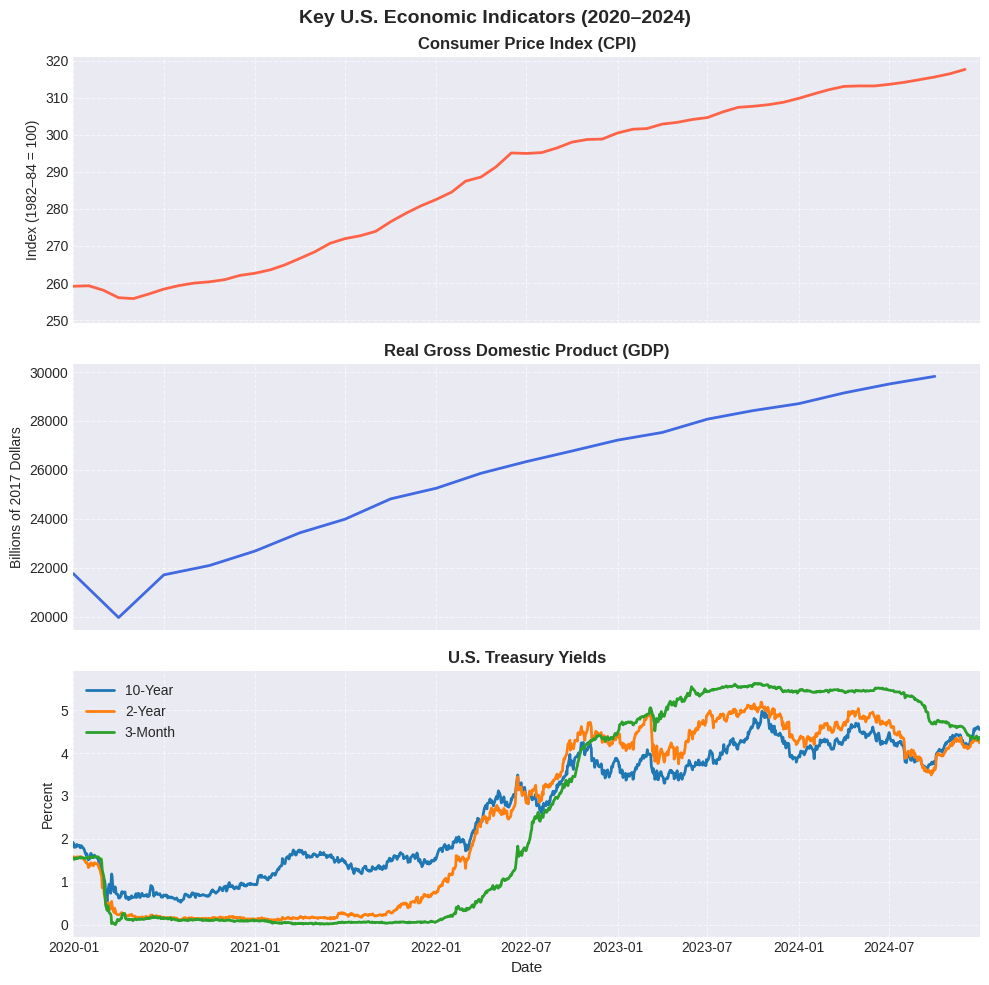

In [ ]:
# Plot the macroeconomic trends over the study period
# Create subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# --- CPI ---
axes[0].plot(cpi_raw.index, cpi_raw['CPI'], color='tomato', linewidth=2)
axes[0].set_title('Consumer Price Index (CPI)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Index (1982–84 = 100)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- GDP ---
axes[1].plot(gdp_raw.index, gdp_raw['Real_GDP'], color='royalblue', linewidth=2)
axes[1].set_title('Real Gross Domestic Product (GDP)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Billions of 2017 Dollars')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Treasury Yields ---
axes[2].plot(t_yield_raw.index, t_yield_raw['10Y_Yield'], label='10-Year', color='#1f77b4', linewidth=2)
axes[2].plot(t_yield_raw.index, t_yield_raw['2Y_Yield'], label='2-Year', color='#ff7f0e', linewidth=2)
axes[2].plot(t_yield_raw.index, t_yield_raw['3M_Yield'], label='3-Month', color='#2ca02c', linewidth=2)
axes[2].set_title('U.S. Treasury Yields', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Percent')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)


# --- Shared x-axis label ---
plt.xlabel('Date', fontsize=11)
plt.suptitle('Key U.S. Economic Indicators (2020–2024)', fontsize=14, fontweight='bold')
plt.xlim(pd.to_datetime(start_date),
         pd.to_datetime(end_date))

plt.tight_layout()
plt.show()



# <h3>Evaluate the relationship between the investment bank stock returns and the S&P 500 stock returns as a proxy for the U.S. stock market

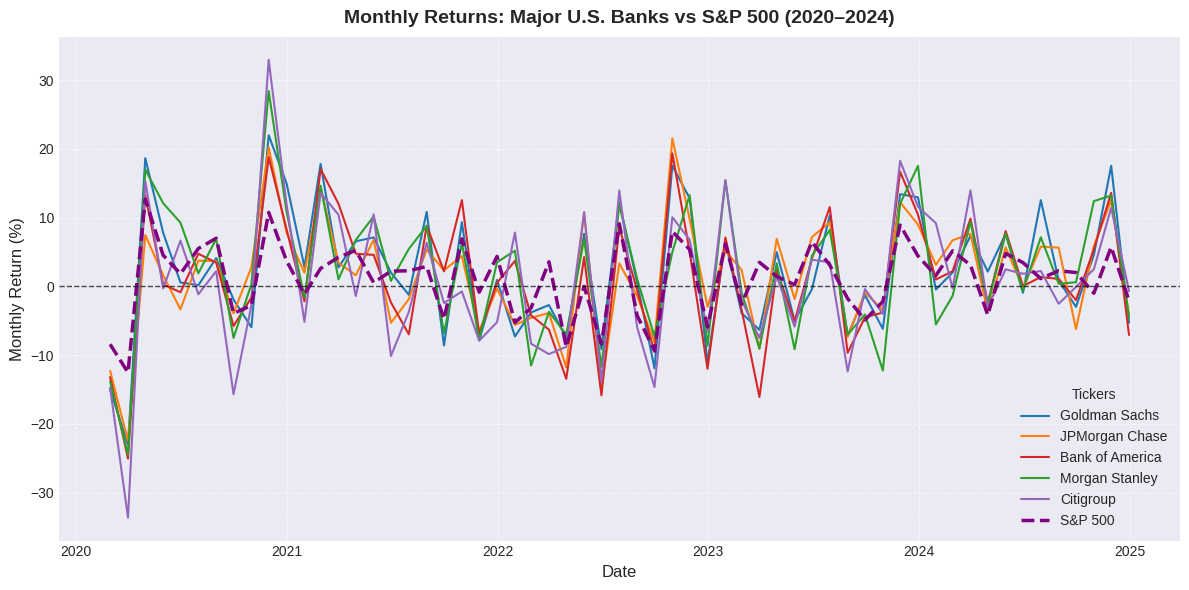

In [ ]:
# --- Plot The Monthly Returns of the Banks vs S&P 500 ---

plt.figure(figsize=(12,6))

# Plot the bank returns

for bank, color in bank_colors.items():
    plt.plot(monthly_returns.index, monthly_returns[bank], color=color,
             label=banks.get(bank, bank))

# Plot the S&P 500 returns
plt.plot(
    monthly_returns.index,
    monthly_returns['SP500'],
    color='purple', linestyle='--', linewidth=2.5, label='S&P 500'
)

# --- Formatting ---
plt.title('Monthly Returns: Major U.S. Banks vs S&P 500 (2020–2024)',
          fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Monthly Return (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--',
            alpha=0.7)  # zero line
plt.legend(title='Tickers', frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

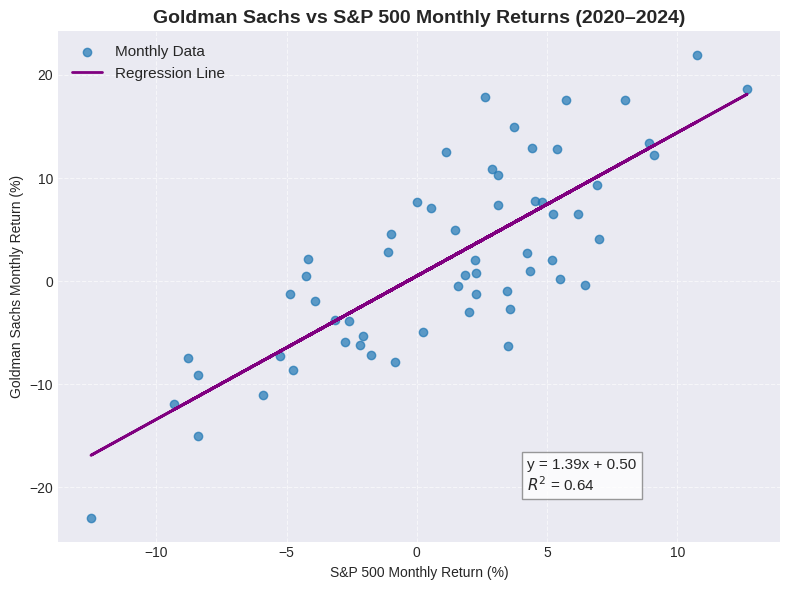

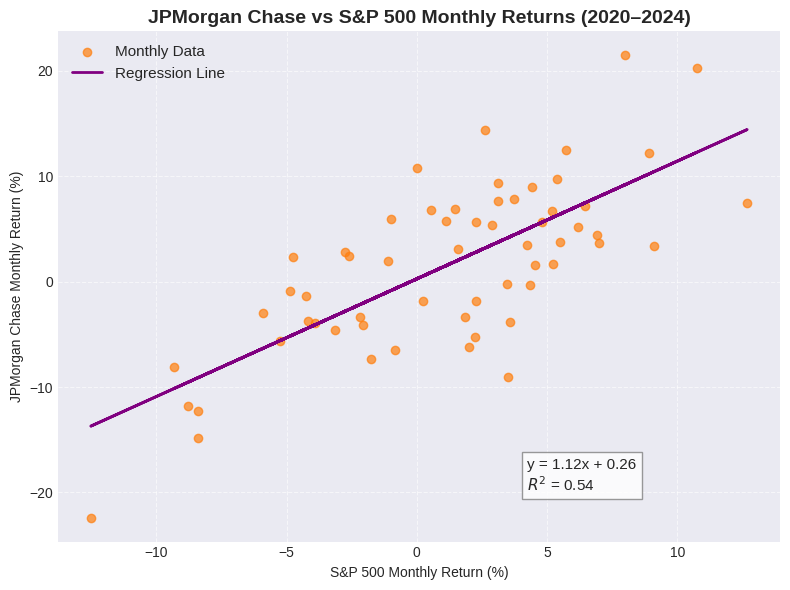

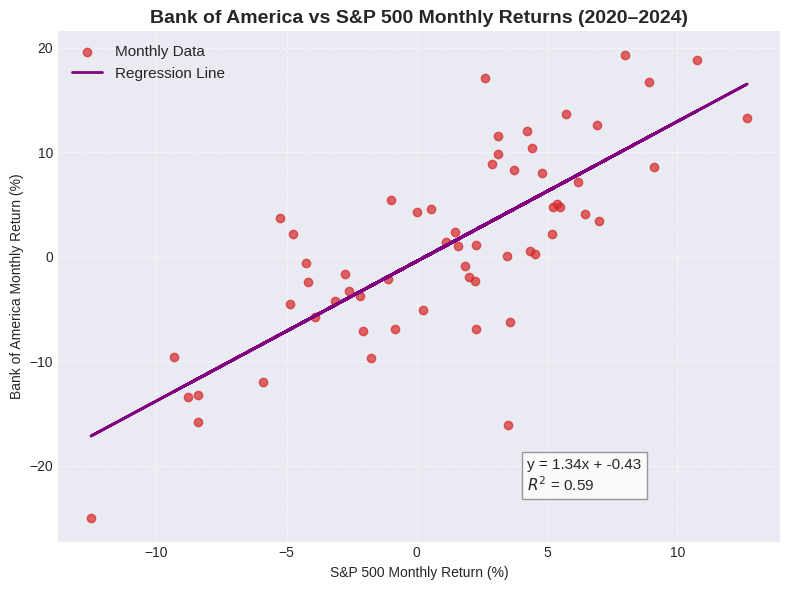

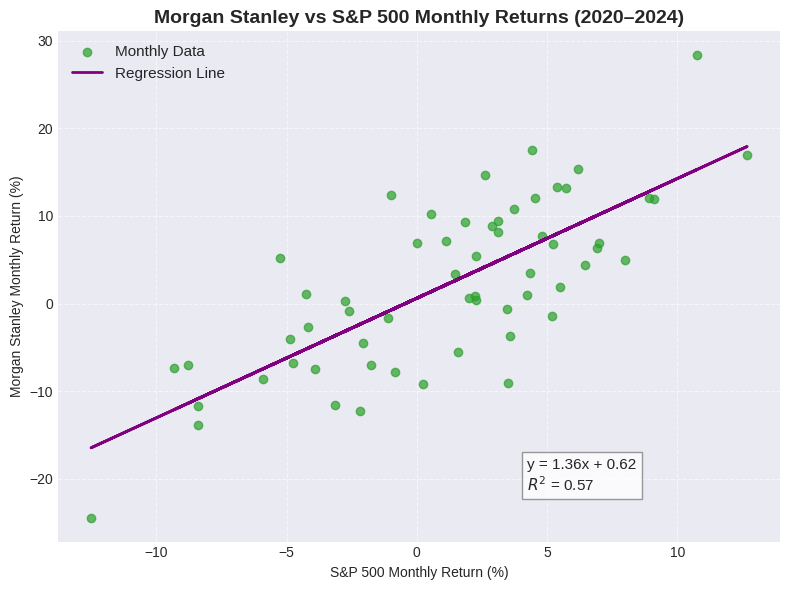

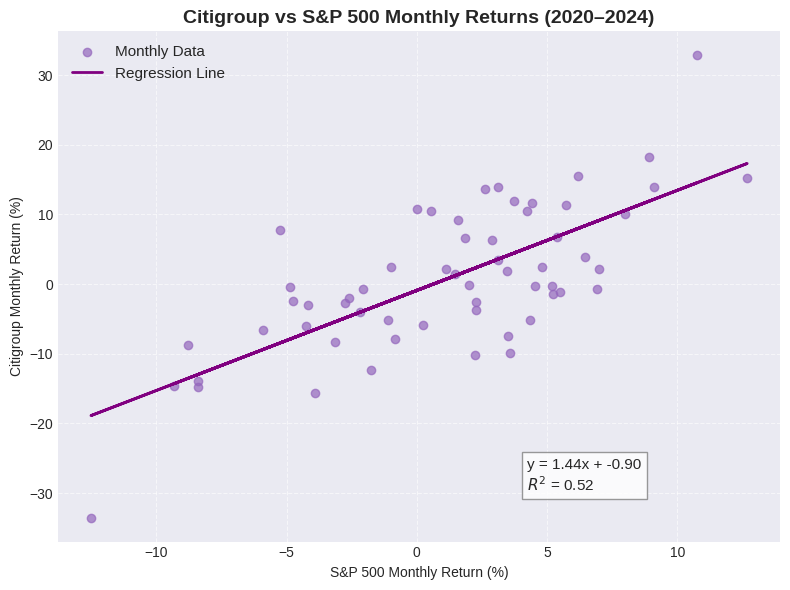

In [ ]:
## ---Loop through each bank and run regression ---
for bank, color in bank_colors.items():
    # Independent (market) and dependent (bank) variables
    X = sm.add_constant(monthly_returns['SP500'])
    y = monthly_returns[bank]

    # Fit regression model
    model = sm.OLS(y, X).fit()
    alpha = model.params['const']
    beta = model.params['SP500']
    r2 = model.rsquared

    # --- Plot results ---
    plt.figure(figsize=(8, 6))
    plt.scatter(monthly_returns['SP500'], y, color=color, alpha=0.7, label='Monthly Data')
    plt.plot(monthly_returns['SP500'], model.predict(X), color='purple', linewidth=2, label='Regression Line')

    plt.title(f'{banks.get(bank,bank)} vs S&P 500 Monthly Returns (2020–2024)', fontsize=14, fontweight='bold')
    plt.xlabel('S&P 500 Monthly Return (%)')
    plt.ylabel(f'{banks.get(bank,bank)} Monthly Return (%)')
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Regression equation + R² annotation
    eq_text = f'y = {beta:.2f}x + {alpha:.2f}\n$R^2$ = {r2:.2f}'
    plt.text(0.65, 0.10, eq_text, transform=plt.gca().transAxes,
             fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.tight_layout()
    plt.show()
    print('\n')

# <h3>Explore the correlation between Inflation (YoY) and investment bank stock price

In [ ]:
# Set up the seaborn color scheme for plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#combine data
df = pd.concat([cpi, monthly_prices], axis=1).dropna()

print(f"\n Analysis Period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f" Total Months: {len(df)}\n")


# STATISTICAL ANALYSIS
print("=" * 70)
print("CORRELATION: Inflation vs Stock Prices")
print("=" * 70)

correlations = {}
for ticker in tickers:
    corr, p_value = stats.pearsonr(df['Inflation_Rate_YoY'], df[ticker])
    correlations[ticker] = {'correlation': corr, 'p_value': p_value}

    # Determine significance
    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    print(f"{banks[ticker]:20s} Correlation: {corr:+.3f} {sig} (p={p_value:.4f})")

print("=" * 70)
print("Significance: *** p<0.01, ** p<0.05, * p<0.10")
print()


 Analysis Period: January 2020 to December 2024
 Total Months: 60

CORRELATION: Inflation vs Stock Prices
Goldman Sachs        Correlation: +0.179  (p=0.1714)
JPMorgan Chase       Correlation: -0.045  (p=0.7331)
Morgan Stanley       Correlation: +0.356 *** (p=0.0053)
Bank of America      Correlation: +0.428 *** (p=0.0007)
Citigroup            Correlation: -0.032  (p=0.8103)
Significance: *** p<0.01, ** p<0.05, * p<0.10



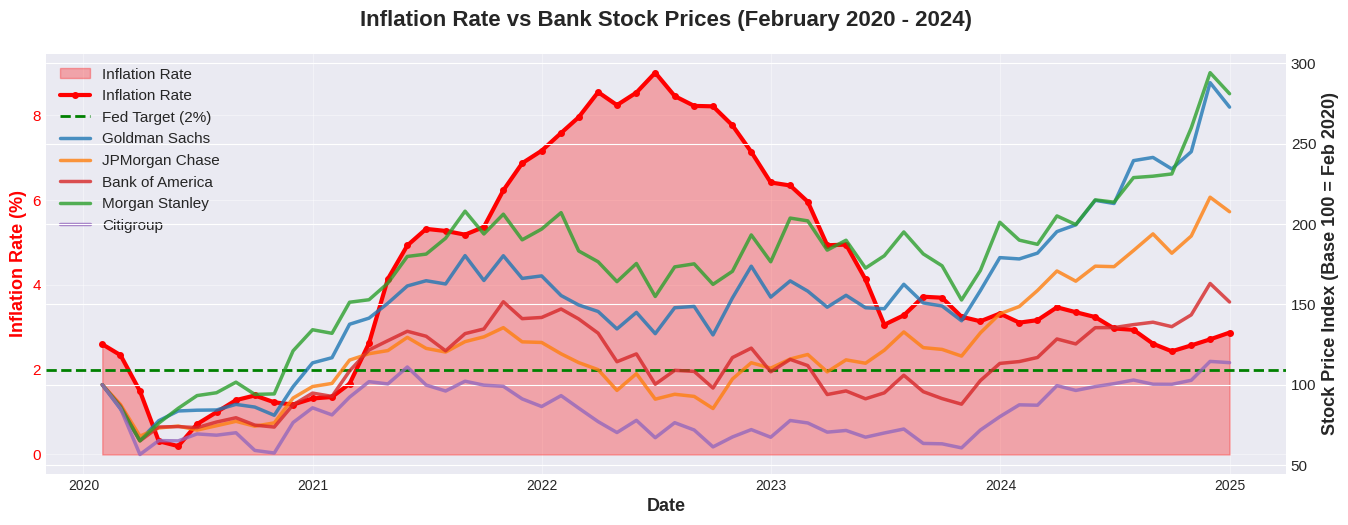

In [ ]:
# VISUALIZATION

# Create a single figure with 3 subplots
fig = plt.figure(figsize=(16, 12))


# CHART 1: INFLATION VS STOCK PRICES (DUAL AXIS)

ax1 = plt.subplot(2, 2, (1, 2))  # Top row, spans 2 columns
ax1_twin = ax1.twinx()

# Normalize stock prices to base 100
normalized = (df[tickers] / df[tickers].iloc[0]) * 100

# Plot inflation (left axis)
ax1.fill_between(df.index, df['Inflation_Rate_YoY'], alpha=0.3, color='red', label='Inflation Rate')
ax1.plot(df.index, df['Inflation_Rate_YoY'], color='red', linewidth=3,
         marker='o', markersize=4, label='Inflation Rate')
ax1.axhline(y=2, color='green', linestyle='--', linewidth=2, label='Fed Target (2%)')
ax1.set_ylabel('Inflation Rate (%)', fontsize=13, color='red', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='red', labelsize=11)
ax1.set_xlabel('Date', fontsize=13, fontweight='bold')

# Plot stock prices (right axis)
for bank, color in bank_colors.items():
    ax1_twin.plot(df.index, normalized[bank], label=banks.get(bank, bank),
                  linewidth=2.5, alpha=0.8, color=color)

ax1_twin.set_ylabel('Stock Price Index (Base 100 = Feb 2020)', fontsize=13, fontweight='bold')
ax1_twin.tick_params(labelsize=11)

# Title and legend
ax1.set_title('Inflation Rate vs Bank Stock Prices (February 2020 - 2024)',
              fontsize=16, fontweight='bold', pad=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.4)

 Chart 2: Correlation Heatmap


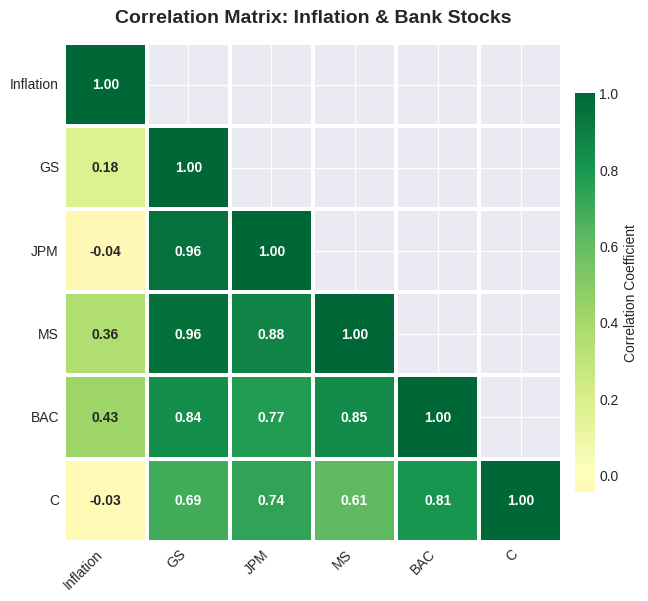

In [ ]:
# CHART 2: CORRELATION HEATMAP

print("=" * 70)
print(" Chart 2: Correlation Heatmap")
print("=" * 70)
fig2, ax2 = plt.subplots(figsize=(7, 6))
# Create correlation matrix
correlation_matrix = df[['Inflation_Rate_YoY'] + tickers].corr()
# Create mask for upper triangle (only show lower half)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
# Create heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=1.5,
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8, 'pad': 0.02},
            annot_kws={'size': 10, 'weight': 'bold'}, ax=ax2)
ax2.set_title('Correlation Matrix: Inflation & Bank Stocks',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xticklabels(['Inflation', 'GS', 'JPM', 'MS', 'BAC', 'C'],
                     rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(['Inflation', 'GS', 'JPM', 'MS', 'BAC', 'C'],
                     rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n")

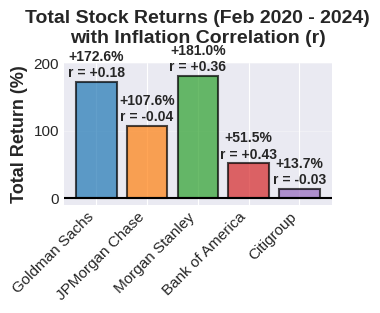

KEY FINDINGS:
1. Inflation peaked at 9.00% in June 2022
2. Best performing bank: Morgan Stanley (+181.0%)
3. Worst performing bank: Citigroup (+13.7%)
4. Average correlation with inflation: 0.177


In [ ]:
# CHART 3: PERFORMANCE SUMMARY BAR CHART

ax3 = plt.subplot(2, 2, 4)  # Bottom right

# Calculate total returns
returns = []
corr_values = []
bank_names = []

for ticker in tickers:
    start_price = df[ticker].iloc[0]
    end_price = df[ticker].iloc[-1]
    total_return = ((end_price - start_price) / start_price) * 100
    returns.append(total_return)
    corr_values.append(correlations[ticker]['correlation'])
    bank_names.append(banks[ticker])

# Create bar chart
x_pos = np.arange(len(bank_names))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = ax3.bar(x_pos, returns, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)


for i, (bar, ret, corr) in enumerate(zip(bars, returns, corr_values)):
    height = bar.get_height()

    offset = 3 if height > 0 else -3
    ax3.text(bar.get_x() + bar.get_width()/2., height + offset,
             f'{ret:+.1f}%\nr = {corr:+.2f}',
             ha='center', va='bottom' if height > 0 else 'top',
             fontsize=10, fontweight='bold')

ax3.axhline(y=0, color='black', linewidth=1.5)
ax3.set_ylabel('Total Return (%)', fontsize=13, fontweight='bold')
ax3.set_title('Total Stock Returns (Feb 2020 - 2024)\nwith Inflation Correlation (r)',
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(bank_names, rotation=45, ha='right', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(labelsize=11)


y_min, y_max = ax3.get_ylim()
ax3.set_ylim(y_min - 10, y_max + 10)

plt.tight_layout()
plt.savefig('bank_inflation_analysis_simplified.png', dpi=300, bbox_inches='tight')

plt.show()


# KEY FINDINGS SUMMARY
print("=" * 70)
print("KEY FINDINGS:")
print("=" * 70)
print(f"1. Inflation peaked at {df['Inflation_Rate_YoY'].max():.2f}% in {df['Inflation_Rate_YoY'].idxmax().strftime('%B %Y')}")
print(f"2. Best performing bank: {bank_names[returns.index(max(returns))]} ({max(returns):+.1f}%)")
print(f"3. Worst performing bank: {bank_names[returns.index(min(returns))]} ({min(returns):+.1f}%)")
print(f"4. Average correlation with inflation: {np.mean(corr_values):.3f}")
print("=" * 70)

# <h3>Explore the correlation between Year over Year Gross Domestic Product (GDP) and investment bank stock price


Analysis Period: January 2020 to October 2024
Total Months: 58



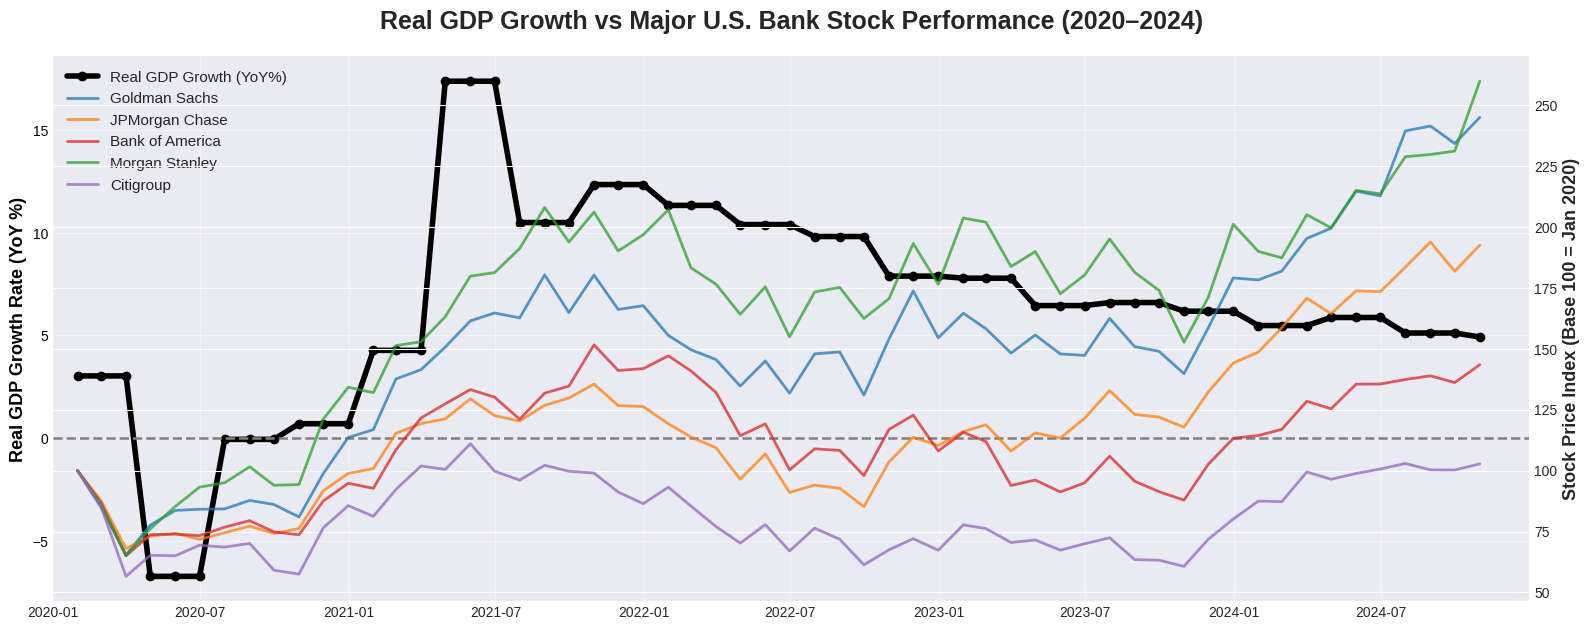

In [ ]:
# Create a dataframe containing the GDP data and the monthly stock price data

df = pd.concat([gdp, monthly_prices], axis=1).dropna(subset=['Real_GDP'])
df.index = pd.to_datetime(df.index)
df = df.sort_index()

print(f"\nAnalysis Period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Total Months: {len(df)}\n")

# Normalize stock prices to Base 100
normalized = (df[tickers] / df[tickers].iloc[0]) * 100

# Create figure
fig = plt.figure(figsize=(16, 12))
ax1 = plt.subplot(2, 2, (1, 2))
ax2 = ax1.twinx()

# Plot GDP Growth
ax1.plot(df.index, df['GDP_Growth_YoY'],
         color='black', linewidth=4,
         marker='o', markersize=6,
         label='Real GDP Growth (YoY%)')

ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1.8)
ax1.set_ylabel('Real GDP Growth Rate (YoY %)', fontsize=13, color='black', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# Plot Bank Stocks
for ticker, color in bank_colors.items():
    ax2.plot(df.index, normalized[ticker], label=banks.get(ticker,ticker),
             linewidth=2, alpha=0.75, linestyle='-', color=color)

ax2.set_ylabel('Stock Price Index (Base 100 = Jan 2020)', fontsize=13, fontweight='bold')

# Title
ax1.set_title('Real GDP Growth vs Major U.S. Bank Stock Performance (2020–2024)',
              fontsize=18, fontweight='bold', pad=20)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, framealpha=0.9)

# Time period
ax1.set_xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2024-12-31"))
ax2.set_xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2024-12-31"))

# Layout
ax1.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

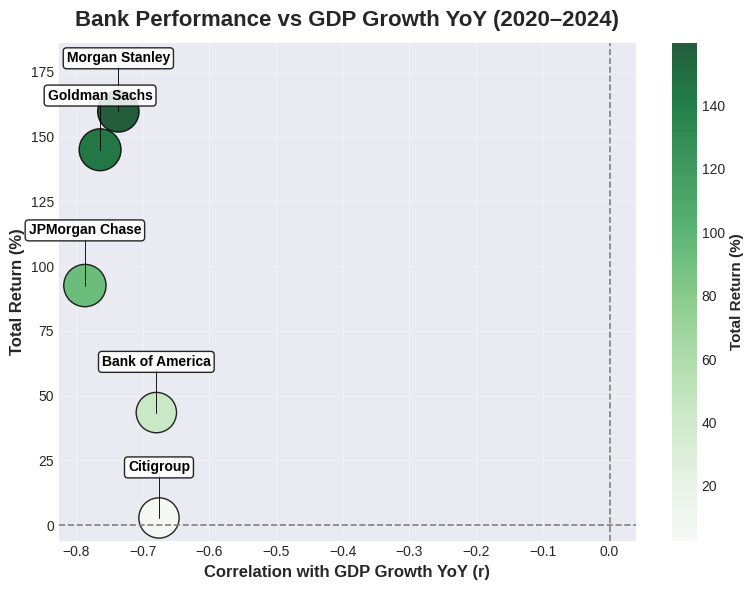

In [ ]:
# GDP - Bubble Chart

# Ensure GDP YoY exists
df['GDP_Growth_YoY'] = df['Real_GDP'].pct_change(12) * 100

# Bank Tickers + Names
bank_tickers = list(banks.keys())
bank_names  = list(banks.values())

# Total Returns (since start of period)
returns = (normalized.loc[df.index[-1], bank_tickers] - 100).values

# 12-Month Rolling Correlation with **GDP YoY**
corr_values = [
    df['GDP_Growth_YoY'].rolling(12).corr(df[ticker]).iloc[-1]
    for ticker in bank_tickers
]
# Bubble Sizes
sizes = (abs(np.array(corr_values)) * 800) + 300

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    corr_values,
    returns,
    s=sizes,
    c=returns,
    cmap='Greens',
    edgecolor='black',
    alpha=0.85
)

# Label Placement
for i, name in enumerate(bank_names):
    ax.text(
        corr_values[i],
        returns[i] + (sizes[i] * 0.02),
        name,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.25',
            alpha=0.85
        )
    )
    ax.plot(
        [corr_values[i], corr_values[i]],
        [returns[i], returns[i] + (sizes[i] * 0.02)],
        color="black", linewidth=0.7, alpha=0.9
    )

# Reference Lines
ax.axvline(0, color='gray', linestyle='--', linewidth=1.2)
ax.axhline(0, color='gray', linestyle='--', linewidth=1.2)

# Labels
ax.set_xlabel('Correlation with GDP Growth YoY (r)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Return (%)', fontsize=12, fontweight='bold')
ax.set_title('Bank Performance vs GDP Growth YoY (2020–2024)', fontsize=16, fontweight='bold', pad=12)

# Color Bar
cbar = plt.colorbar(scatter)
cbar.set_label('Total Return (%)', fontsize=11, fontweight='bold')

# Style
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

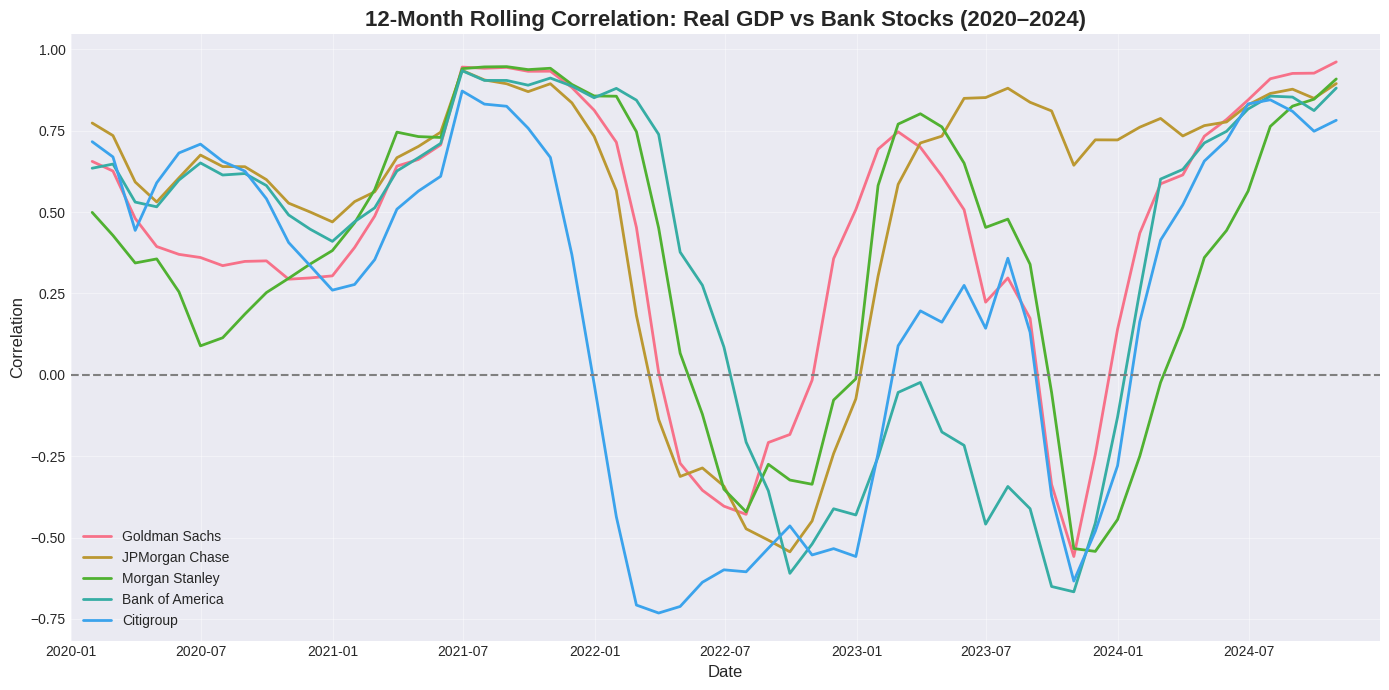

In [ ]:
## --- GDP - Line Graph - Rolling correlation ---

# Data buffer years for rolling calculations
start_buffer = "2018-01-01"
stock_buffer = "2019-01-01"

# Collect GDP from FRED using the buffered start date
fred = Fred(api_key='e5da21be04732c1ce27643009e63c25a')
gdp_raw = fred.get_series('GDPC1',
                          observation_start=start_buffer,
                          observation_end=end_date).to_frame('Real_GDP')

# Quarterly to monthly
gdp = gdp_raw.resample('ME').ffill()
gdp['GDP_Growth_YoY'] = gdp['Real_GDP'].pct_change(12) * 100

# Re-download stock data using the buffer period
price_data_all = yf.download(tickers, start=stock_buffer, end=end_date, auto_adjust=True, progress=False)['Close']
monthly_prices_all = price_data_all.resample('ME').last()

# Combine into a dataframe
df = pd.concat([gdp, monthly_prices_all], axis=1).dropna(subset=['Real_GDP'])
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Find index location of the first date
start_loc = df.index.searchsorted(pd.to_datetime(start_date), side='left')

# Check if start_loc is within bounds
if start_loc < len(df) and not df[tickers].iloc[start_loc].isnull().all():
    normalized = (df[tickers] / df[tickers].iloc[start_loc]) * 100
else:
    print(f"Error: Could not find a valid start date for normalization on or after {start_date}. DataFrame might be empty or all stock data is NaN at the start.")
    normalized = pd.DataFrame()


# 12 Month Rolling Correlation Graph
window = 12
rolling_corr = pd.DataFrame(index=df.index)

# Only banks from my dictionary
bank_tickers_only = list(banks.keys())

if 'Real_GDP' in df.columns and bank_tickers_only:
    for ticker in bank_tickers_only:
        if ticker in df.columns:
            rolling_corr[banks[ticker]] = (
                df['Real_GDP']
                .rolling(window)
                .corr(df[ticker])
            )
        else:
            print(f"Warning: Ticker {ticker} not found in DataFrame for rolling correlation.")


    # Drop rows where all correlations are blank
    rolling_corr.dropna(how='all', inplace=True)


    # Show 2020-2024
    rolling_corr_display = rolling_corr.loc[start_date:].copy()


    if rolling_corr_display.empty:
         print(f"Error: No valid rolling correlation data available for the display period ({start_date}-).")
    else:
        # Plot correlation
        plt.figure(figsize=(14, 7))

        for col in rolling_corr_display.columns:
            plt.plot(rolling_corr_display.index, rolling_corr_display[col], linewidth=2, label=col)

        plt.axhline(0, color='gray', linestyle='--', linewidth=1.5)
        plt.title('12-Month Rolling Correlation: Real GDP vs Bank Stocks (2020–2024)', fontsize=16, fontweight='bold')
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Correlation', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.4)

        # Force x-axis to show fully
        plt.xlim(pd.to_datetime('2020-01-01'), pd.to_datetime('2024-12-31'))


        plt.tight_layout()
        plt.show()
else:
     print("Error: 'Real_GDP' not in DataFrame or no bank tickers available for correlation calculation.")

# <h3> Investigating the Relationship Between Treasury Yield and Investment Bank Stock Returns

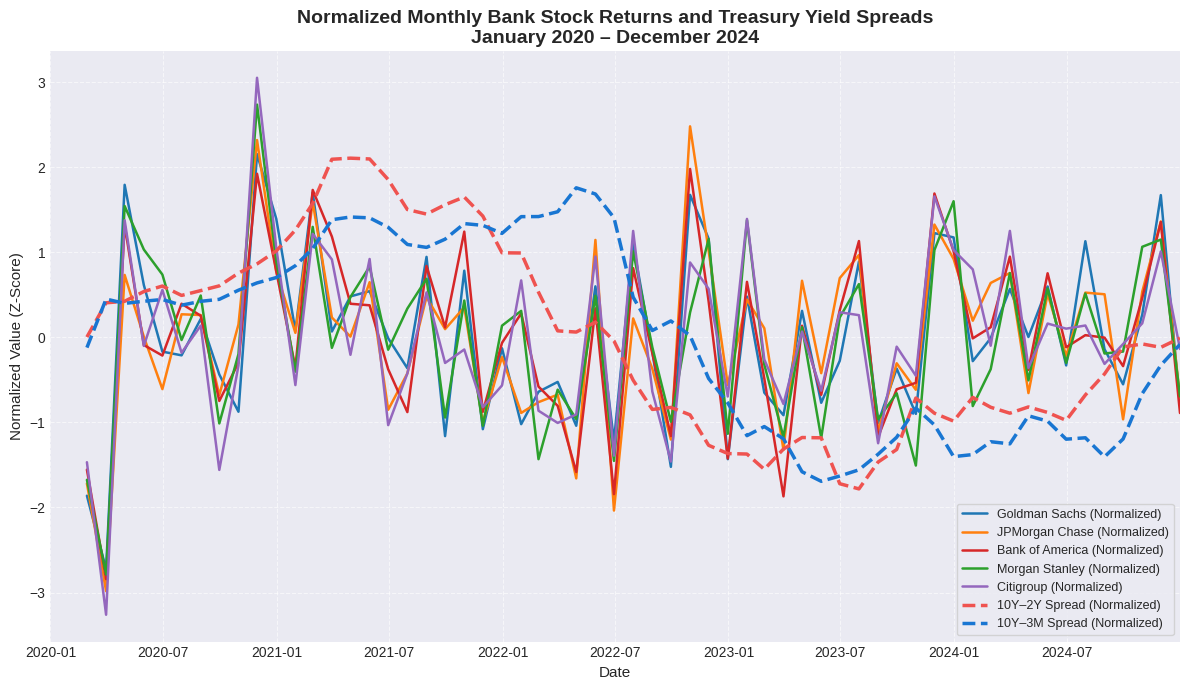

In [ ]:
# --- Normalize Stock Returns and compare to the Normalized 10Y-2Y Treasury Yield Spread ---

# Z-score normalization
returns_z = (m_returns - m_returns.mean()) / m_returns.std()
spread_z = (spread_m[['10Y2Y_Spread', '10Y3M_Spread']] -
            spread_m[['10Y2Y_Spread', '10Y3M_Spread']].mean()) / spread_m[['10Y2Y_Spread', '10Y3M_Spread']].std()
#print(returns_z.head())
#print(spread_z.head())

spread_z_color = {'10Y2Y_Spread': '#ef5350',
                  '10Y3M_Spread': '#1976d2'}

spread_labels = {
    '10Y2Y_Spread': '10Y–2Y Spread',
    '10Y3M_Spread': '10Y–3M Spread'
}

# --- Merge data into a single data frame ---
df = pd.concat([returns_z, spread_z], axis=1)
df.dropna(inplace=True)
df.head()

# Chart 1: Normalized Stock Price and 10Y-2Y Treasury Yield Spread

plt.figure(figsize=(12, 7))

# Plot normalized stock prices for each bank
for ticker, color in bank_colors.items():
    if ticker in df.columns:  # avoid missing columns
        plt.plot(df.index, df[ticker],
                 label=f'{banks.get(ticker,ticker)} (Normalized)',
                 color=color, linewidth=1.8)

# Plot normalized Treasury Yield Spread
for spread, color in spread_z_color.items():
    if spread in df.columns:
        plt.plot(df.index, df[spread],
                 label=f"{spread_labels.get(spread, spread)} (Normalized)",
                 color=color, linewidth=2.5, linestyle="--")

# Add titles and labels
plt.title("Normalized Monthly Bank Stock Returns and Treasury Yield Spreads\nJanuary 2020 – December 2024",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=11)
plt.ylabel("Normalized Value (Z-Score)", fontsize=11)

plt.legend(loc='lower right', fontsize=9, frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.xlim(pd.to_datetime(start_date),
         pd.to_datetime(end_date))

# Save and show the plot
plt.savefig("normalized_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# --- Perform Statistical Analyses USING NORMALIZED DATA ---

summary = df.describe()
correlation_matrix = df.corr()

# Define which spread variables you want to test
spread_vars = ['10Y2Y_Spread', '10Y3M_Spread']

spread_labels = {
    '10Y2Y_Spread': '10Y–2Y Treasury Yield Spread',
    '10Y3M_Spread': '10Y–3M Treasury Yield Spread'
}

# Dictionary to correlations and p-values
correlations = {}

subtitle = 'January, 2020 - December, 2024'

for ticker in tickers:
    correlations[ticker] = {}  # each ticker will store results for multiple spreads

    for spread in spread_vars:
        if spread in df.columns:
            corr, p_value = stats.pearsonr(df[spread], df[ticker])
            correlations[ticker][spread] = {'correlation': corr, 'p_value': p_value}

# Prepare data for tabulate
for spread in spread_vars:
    table_data = []

    for bank_ticker, spreads in correlations.items():
        if spread in spreads:
            values = spreads[spread]
            full_name = banks.get(bank_ticker, bank_ticker)
            # Add asterisk for significance
            label = full_name + (" *" if values['p_value'] < 0.05 else "")
            table_data.append([
                label,
                f"{values['correlation']:+.3f}",
                f"{values['p_value']:.4f}"
            ])

    # Sort table by correlation descending
    table_data.sort(key=lambda x: float(x[1]), reverse=True)

    # Table headers
    headers = ["Bank", "Correlation", "p-value"]

    # Generate table string
    table_str = tabulate(table_data, headers=headers, tablefmt="fancygrid")

    # Center title dynamically using the spread label
    table_width = max(len(line) for line in table_str.split("\n"))
    spread_name = spread_labels.get(spread, spread)
    title = f"{spread_name} vs. Monthly Investment Bank Stock Returns (Normalized)"

    print("\n" + title.center(table_width))
    print(subtitle.center(table_width) + "\n")
    print(table_str)


  # Export to text file
    with open(f"{spread_name}_correlation_table.txt", "w") as f:
      f.write(table_str)


10Y–2Y Treasury Yield Spread vs. Monthly Investment Bank Stock Returns (Normalized)
      January, 2020 - December, 2024     

Bank               Correlation    p-value
---------------  -------------  ---------
Bank of America          0.117     0.3761
Morgan Stanley           0.108     0.4146
Goldman Sachs            0.069     0.6049
Citigroup                0.01      0.938
JPMorgan Chase          -0.044     0.7394

10Y–3M Treasury Yield Spread vs. Monthly Investment Bank Stock Returns (Normalized)
      January, 2020 - December, 2024     

Bank               Correlation    p-value
---------------  -------------  ---------
Morgan Stanley          -0.003     0.98
Bank of America         -0.029     0.8251
Goldman Sachs           -0.033     0.8062
Citigroup               -0.097     0.4651
JPMorgan Chase          -0.163     0.2175


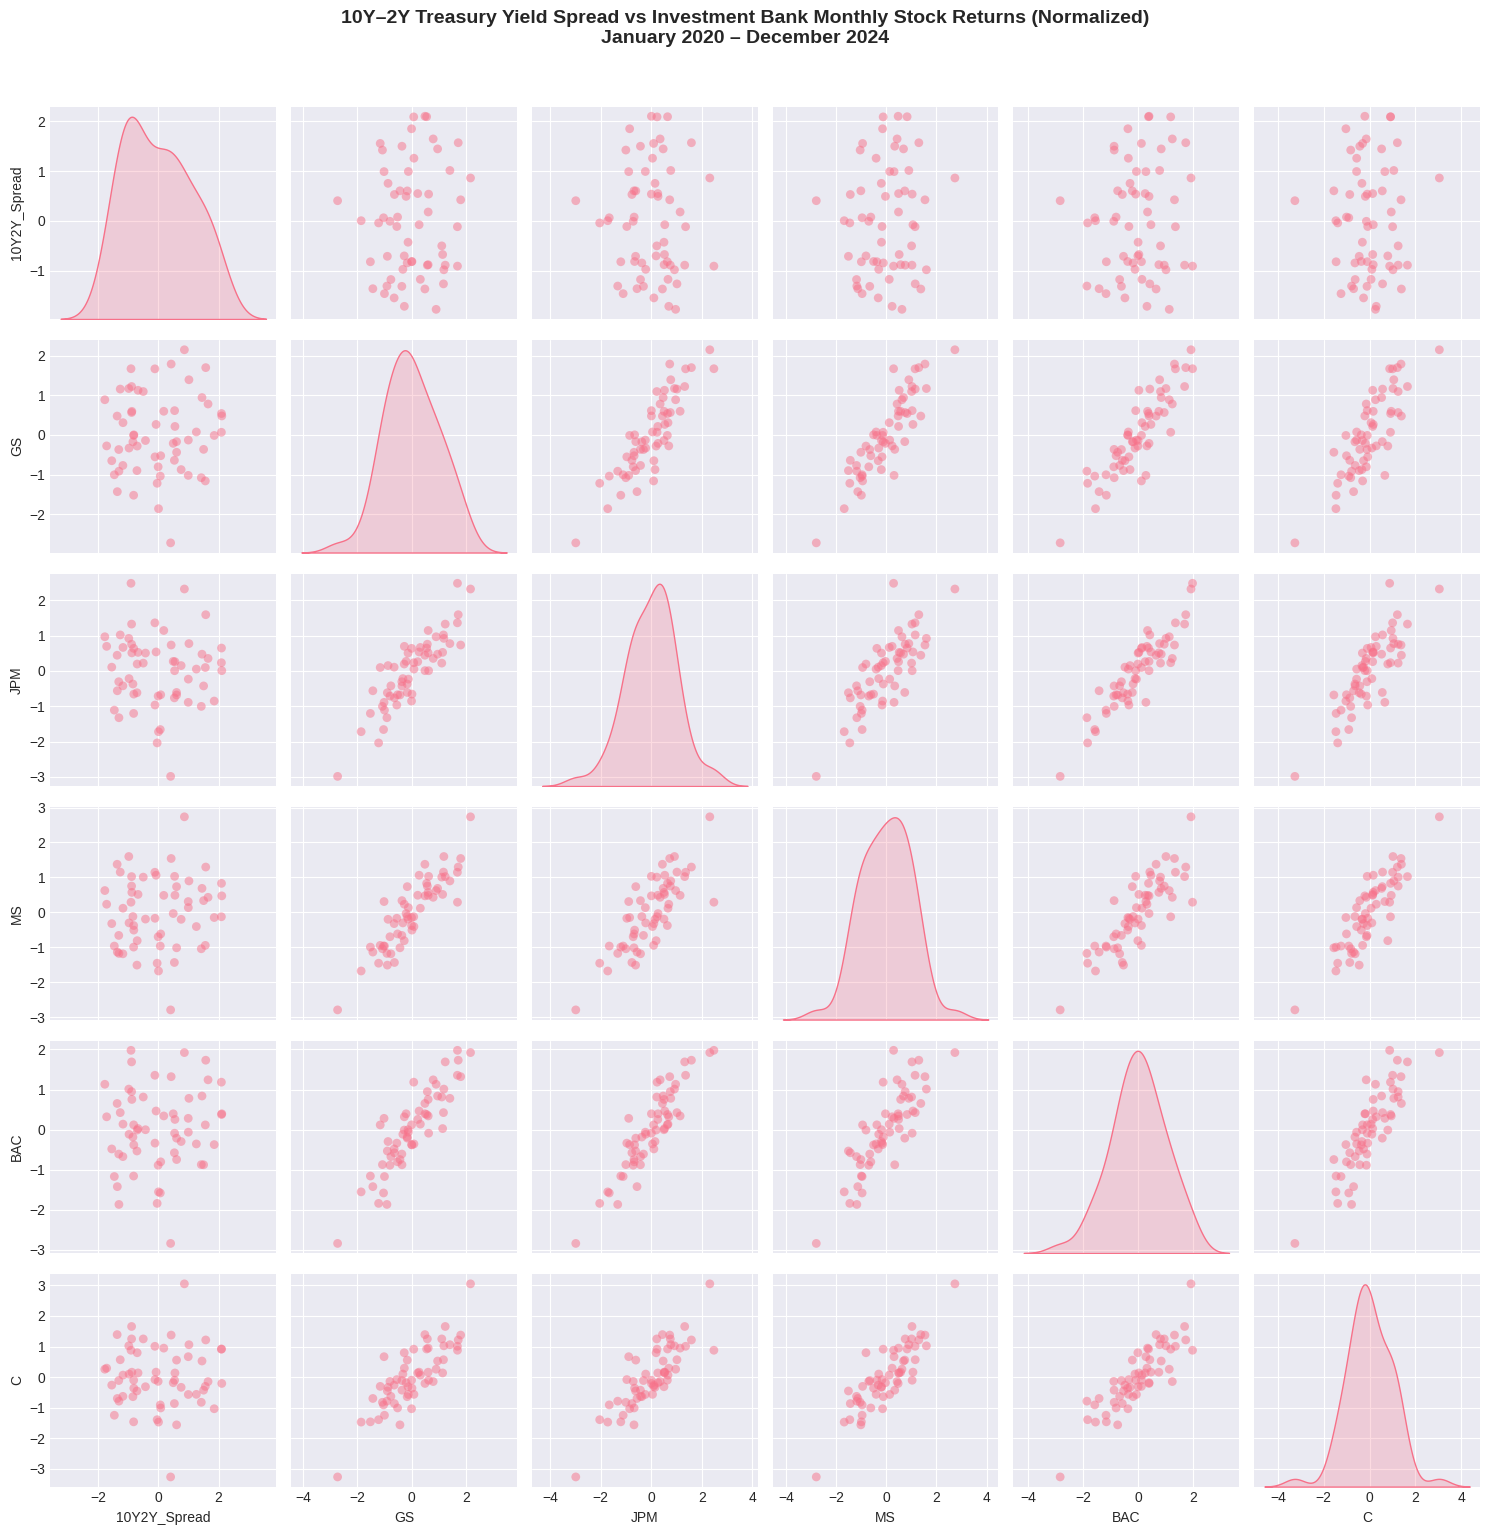

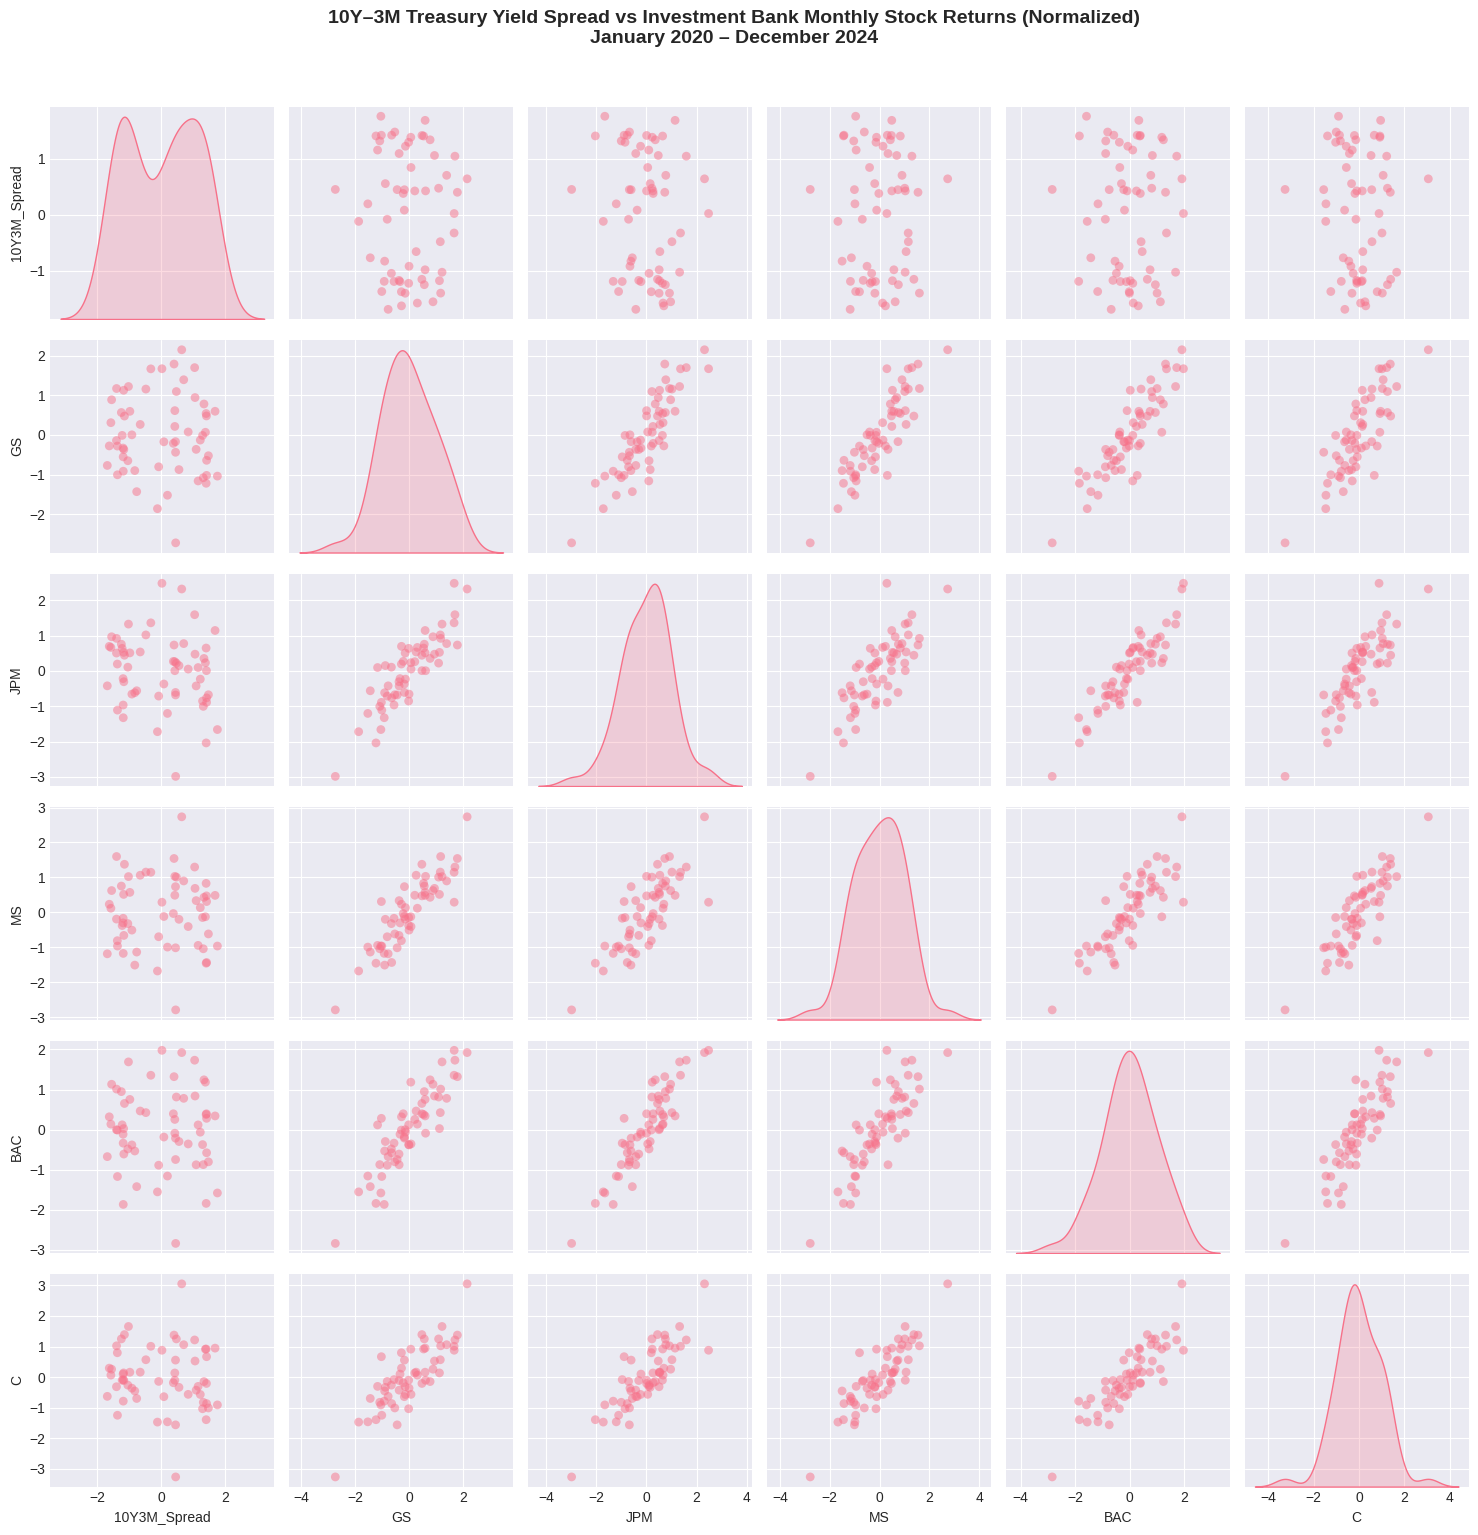

In [ ]:
# --- Create Pairplot of Stock Price vs. Treasury Yield

# Loop through each spread variable
for spread in spread_vars:
    if spread in df.columns:
        # Select only the current spread and all bank columns
        cols_to_plot = [spread] + tickers
        plot_data = df[cols_to_plot].dropna()

        # Create the pairplot
        g = sns.pairplot(
            plot_data,
            diag_kind='kde',
            plot_kws={'alpha': 0.5, 's': 40, 'edgecolor': 'none'}
        )

        # Title and layout adjustments
        g.fig.suptitle(
            f"{spread_labels.get(spread, spread)} vs Investment Bank Monthly Stock Returns (Normalized)\nJanuary 2020 – December 2024",
            y=1.02,
            fontsize=14,
            fontweight='bold'
        )
        plt.tight_layout()

        # --- Save figure with spread name ---
        filename = f"pairplot_{spread}.png"
        g.fig.savefig(f'{filename}', dpi=300, bbox_inches='tight')


        # Show the plot
        plt.show()
        print('\n')


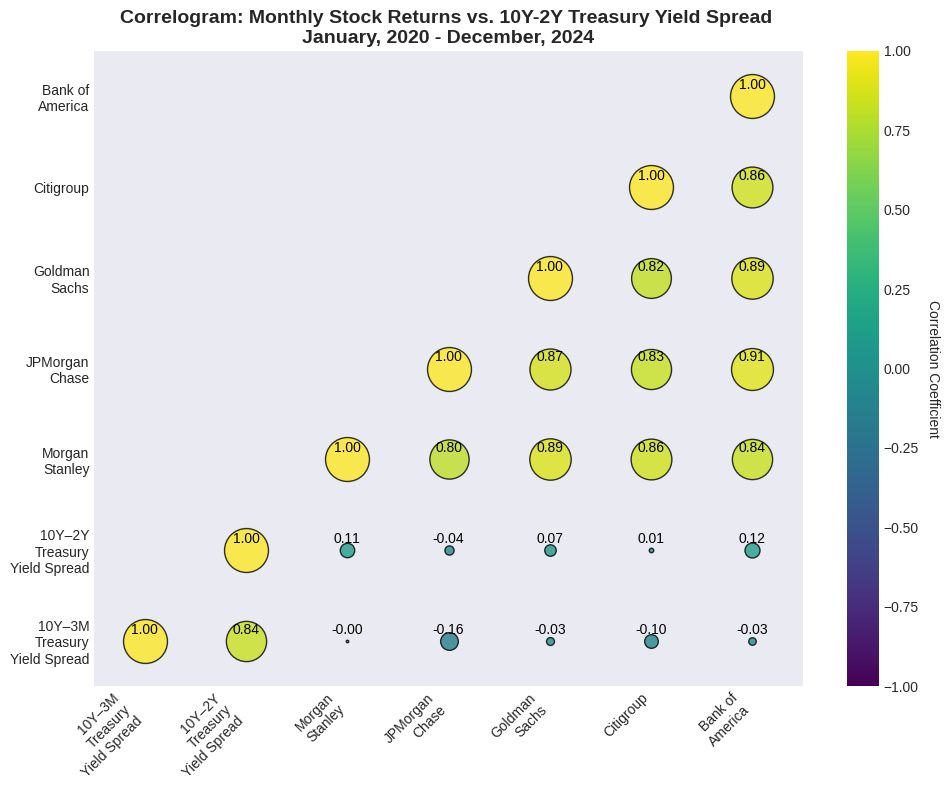

In [ ]:
# CHART: CORRELATION circle chart

corr = df.corr()
columns = corr.columns

label_map = {**banks, **spread_labels}

def break_label(label, max_len=12):
    words = label.split()
    lines = []
    current_line = ""

    for word in words:
        # Check if adding the next word exceeds max_len
        if len(current_line) + len(word) + (1 if current_line else 0) <= max_len:
            # Add word to current line
            current_line += (" " if current_line else "") + word
        else:
            # Start a new line
            lines.append(current_line)
            current_line = word

    # Add the last line
    if current_line:
        lines.append(current_line)

    return '\n'.join(lines)

# Apply line breaks to labels
x_labels = [break_label(label_map.get(col, col)) for col in columns]
y_labels = [break_label(label_map.get(col, col)) for col in columns]

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax=plt.subplots(figsize=(10,8))

cmap = cm.viridis
norm = plt.Normalize(-1, 1)

# Add circles proportional to correlation strength
# Plot circles only for lower triangle
for i in range(len(corr)):
    for j in range(len(corr)):
        if not mask[i, j]:  # only plot if mask is False (lower triangle + diagonal)
            value = corr.iloc[i,j]
            color = cmap(norm(value))
            plt.scatter(j+0.5, i+0.5,
                        s=1000*abs(value),
                        color=color, edgecolor='black',
                        alpha=0.8)
            plt.text(j + 0.5, i + 0.5 - 0.2, f"{value:.2f}",
                     ha='center', va='top', fontsize=10, color='black')

# Set tick labels with line breaks
plt.xticks(np.arange(len(columns)) + 0.5,
           x_labels, rotation=45, ha='right')
plt.yticks(np.arange(len(columns)) + 0.5,
           y_labels, rotation=0)

#Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=15)

plt.title('Correlogram: Monthly Stock Returns vs. 10Y-2Y Treasury Yield Spread \nJanuary, 2020 - December, 2024', fontweight='bold', fontsize=14)
plt.xlim(0, len(columns))
plt.ylim(0, len(columns))
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.grid(False)
plt.tight_layout()

plt.savefig('circle_correlogram_masked.png', dpi=300, bbox_inches='tight')
plt.show()